In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import string
import os
os.makedirs('../data/images', exist_ok=True)

In [51]:
# =============================================================================
# CONFIGURATION
# =============================================================================
 
# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)
 
DISASTER_COLOR     = '#d62728'   # red  → disaster tweets
NON_DISASTER_COLOR = '#1f77b4'   # blue → non-disaster tweets
 
STOPWORDS = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'is', 'it', 'this', 'that', 'i', 'my', 'you', 'we',
    'he', 'she', 'they', 'are', 'was', 'be', 'been', 'have', 'has', 'had',
    'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might',
    'not', 'no', 'so', 'if', 'as', 'by', 'from', 'up', 'about', 'into',
    'than', 'then', 'its', 'our', 'your', 'their', 'what', 'which', 'who',
    'how', 'when', 'where', 'there', 'here', 'all', 'just', 'more', 'also',
    'amp', 'rt', 'via', 'get', 'got', 'new', 'like', 'now', 'one', 'out'
])

In [52]:
# =============================================================================
# LOAD DATA
# =============================================================================
# We load the cleaned and augmented training set produced by the first notebook.
# For EDA we work only on the ORIGINAL rows (not the augmented ones) to avoid
# analyzing artificially generated data as if it were real observations.
 
df_full = pd.read_csv('../data/augmented_train.csv')
df_test  = pd.read_csv('../data/test_cleaned.csv')
 
# Keep only original rows (augmented rows have id > original max id)
original_max_id = df_full['id'].max() // 2
df_train = df_full[df_full['id'] <= original_max_id].copy()
 
print(f"Original training rows : {len(df_train)}")
print(f"Augmented training rows: {len(df_full) - len(df_train)}")
print(f"Test rows              : {len(df_test)}")
print(f"\nColumns: {df_train.columns.tolist()}")
 
# Shorthand masks
DISASTER     = df_train['target_relabeled'] == 1
NON_DISASTER = df_train['target_relabeled'] == 0

Original training rows : 7613
Augmented training rows: 7608
Test rows              : 3263

Columns: ['id', 'keyword', 'location', 'text', 'target', 'word_count', 'unique_word_count', 'char_count', 'mean_word_length', 'url_count', 'hashtag_count', 'mention_count', 'punctuation_count', 'text_cleaned', 'target_relabeled']



--- TARGET DISTRIBUTION ---
target_relabeled
0    4352
1    3261
Name: count, dtype: int64
target_relabeled
0    0.572
1    0.428
Name: proportion, dtype: float64


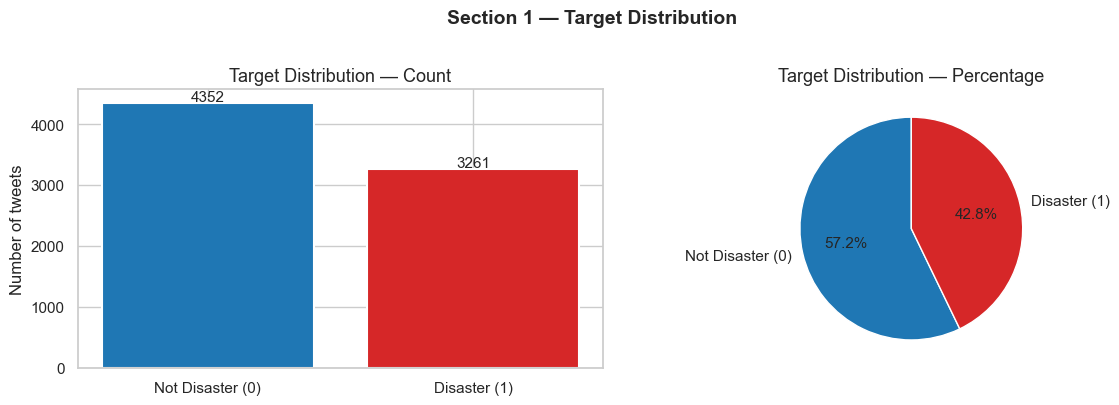

In [53]:
# =============================================================================
# SECTION 1 — TARGET DISTRIBUTION
# =============================================================================
# How many tweets are labeled as real disasters vs non-disasters?
# A heavily imbalanced dataset would require special handling (oversampling,
# class weights etc.). Here the classes are close to balanced, which is good.
 
print("\n--- TARGET DISTRIBUTION ---")
print(df_train['target_relabeled'].value_counts())
print(df_train['target_relabeled'].value_counts(normalize=True).round(3))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Bar chart
counts = df_train['target_relabeled'].value_counts()
axes[0].bar(['Not Disaster (0)', 'Disaster (1)'],
            counts.values,
            color=[NON_DISASTER_COLOR, DISASTER_COLOR],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Distribution — Count', fontsize=13)
axes[0].set_ylabel('Number of tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)
 
# Pie chart
axes[1].pie(counts.values,
            labels=['Not Disaster (0)', 'Disaster (1)'],
            colors=[NON_DISASTER_COLOR, DISASTER_COLOR],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Target Distribution — Percentage', fontsize=13)
 
plt.suptitle('Section 1 — Target Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/images/eda_01_target_distribution.png', bbox_inches='tight')
plt.show()


--- KEYWORD ANALYSIS ---
Number of unique keywords: 222

Top 10 keywords by disaster rate:
                   tweet_count  disaster_rate
keyword                                      
debris                      37       1.000000
derailment                  39       1.000000
wreckage                    39       1.000000
outbreak                    40       0.975000
oil%20spill                 38       0.973684
typhoon                     38       0.973684
suicide%20bombing           33       0.969697
suicide%20bomber            31       0.967742
bombing                     29       0.931034
suicide%20bomb              35       0.914286

Bottom 10 keywords by disaster rate:
             tweet_count  disaster_rate
keyword                                
panicking             33       0.060606
blew%20up             33       0.060606
traumatised           35       0.057143
screaming             36       0.055556
electrocute           32       0.031250
body%20bag            33       0.03030

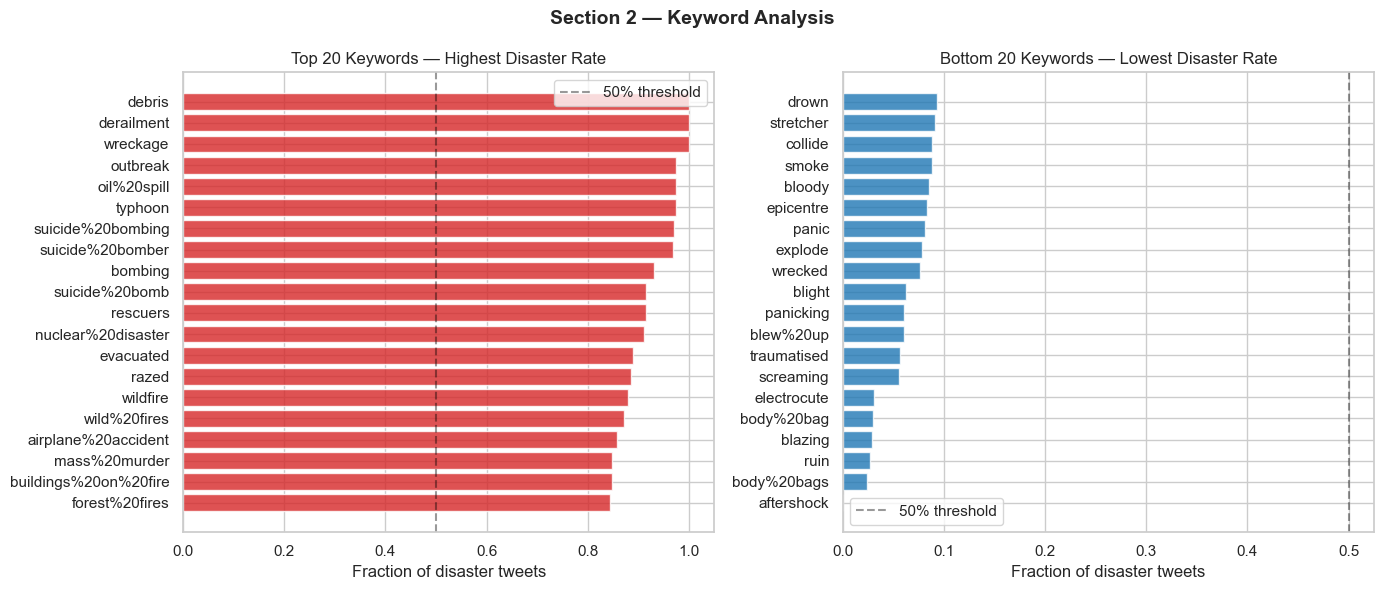

In [54]:
# =============================================================================
# SECTION 2 — KEYWORD ANALYSIS
# =============================================================================
# The 'keyword' column contains predefined disaster-related words used to
# sample tweets. Some keywords (e.g. "earthquake", "flood") appear almost
# exclusively in real disaster tweets, while others (e.g. "ablaze") are
# often used metaphorically. This is important signal for our models.
 
print("\n--- KEYWORD ANALYSIS ---")
 
# Target rate per keyword (fraction of tweets labeled as disaster)
keyword_stats = df_train.groupby('keyword').agg(
    tweet_count=('target_relabeled', 'count'),
    disaster_rate=('target_relabeled', 'mean')
).sort_values('disaster_rate', ascending=False)
 
print(f"Number of unique keywords: {df_train['keyword'].nunique()}")
print("\nTop 10 keywords by disaster rate:")
print(keyword_stats.head(10))
print("\nBottom 10 keywords by disaster rate:")
print(keyword_stats.tail(10))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Top 20 keywords with highest disaster rate
top20 = keyword_stats.head(20)
axes[0].barh(top20.index[::-1], top20['disaster_rate'][::-1],
             color=DISASTER_COLOR, alpha=0.8)
axes[0].set_title('Top 20 Keywords — Highest Disaster Rate', fontsize=12)
axes[0].set_xlabel('Fraction of disaster tweets')
axes[0].axvline(0.5, color='black', linestyle='--', alpha=0.4, label='50% threshold')
axes[0].legend()
 
# Bottom 20 keywords with lowest disaster rate
bot20 = keyword_stats.tail(20)
axes[1].barh(bot20.index[::-1], bot20['disaster_rate'][::-1],
             color=NON_DISASTER_COLOR, alpha=0.8)
axes[1].set_title('Bottom 20 Keywords — Lowest Disaster Rate', fontsize=12)
axes[1].set_xlabel('Fraction of disaster tweets')
axes[1].axvline(0.5, color='black', linestyle='--', alpha=0.4, label='50% threshold')
axes[1].legend()
 
plt.suptitle('Section 2 — Keyword Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/images/eda_02_keyword_analysis.png', bbox_inches='tight')
plt.show()


--- META-FEATURES ANALYSIS ---
                  word_count  unique_word_count  char_count  mean_word_length  \
target_relabeled                                                                
0                      14.71              14.10       95.84              5.87   
1                      15.16              14.66      108.27              6.47   

                  url_count  hashtag_count  mention_count  punctuation_count  
target_relabeled                                                              
0                      0.51           0.40           0.43               6.30  
1                      0.77           0.52           0.28               7.55  


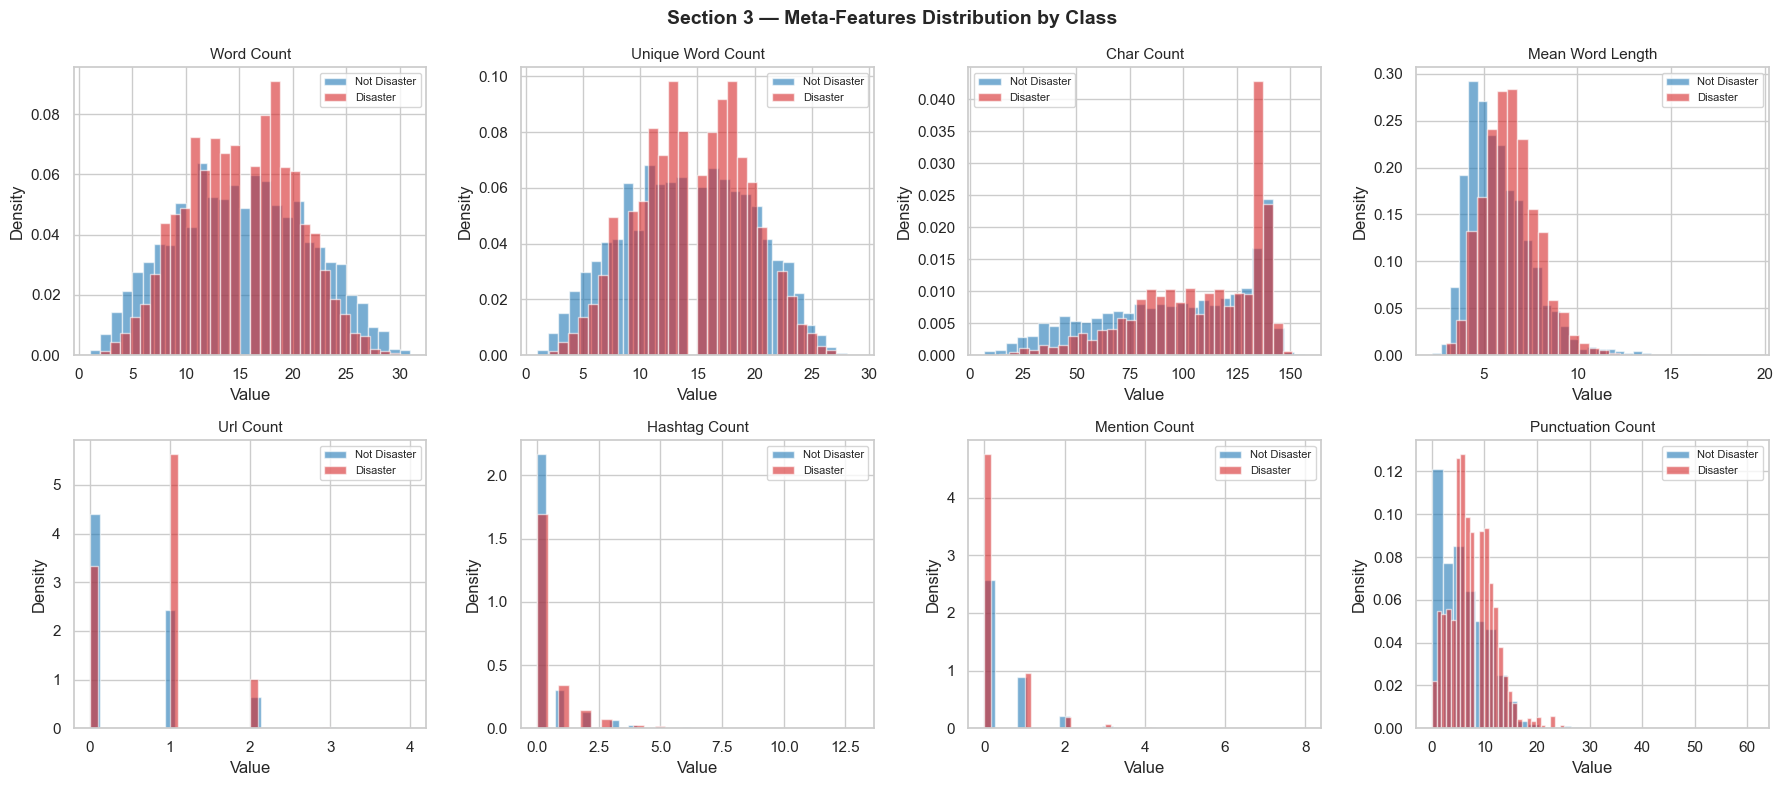

In [55]:
# =============================================================================
# SECTION 3 — META-FEATURES ANALYSIS
# =============================================================================
# We compare the distribution of meta-features (word count, char count, etc.)
# between disaster and non-disaster tweets. If a feature has different
# distributions for the two classes, it is potentially useful for the model.
 
print("\n--- META-FEATURES ANALYSIS ---")
 
META_FEATURES = [
    'word_count', 'unique_word_count', 'char_count',
    'mean_word_length', 'url_count', 'hashtag_count',
    'mention_count', 'punctuation_count'
]
 
print(df_train.groupby('target_relabeled')[META_FEATURES].mean().round(2))
 
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
 
for i, feature in enumerate(META_FEATURES):
    # Plot distribution for each class
    axes[i].hist(df_train.loc[NON_DISASTER, feature],
                 bins=30, alpha=0.6, color=NON_DISASTER_COLOR,
                 label='Not Disaster', density=True)
    axes[i].hist(df_train.loc[DISASTER, feature],
                 bins=30, alpha=0.6, color=DISASTER_COLOR,
                 label='Disaster', density=True)
    axes[i].set_title(feature.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
 
plt.suptitle('Section 3 — Meta-Features Distribution by Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/images/eda_03_meta_features.png', bbox_inches='tight')
plt.show()


--- N-GRAM ANALYSIS ---


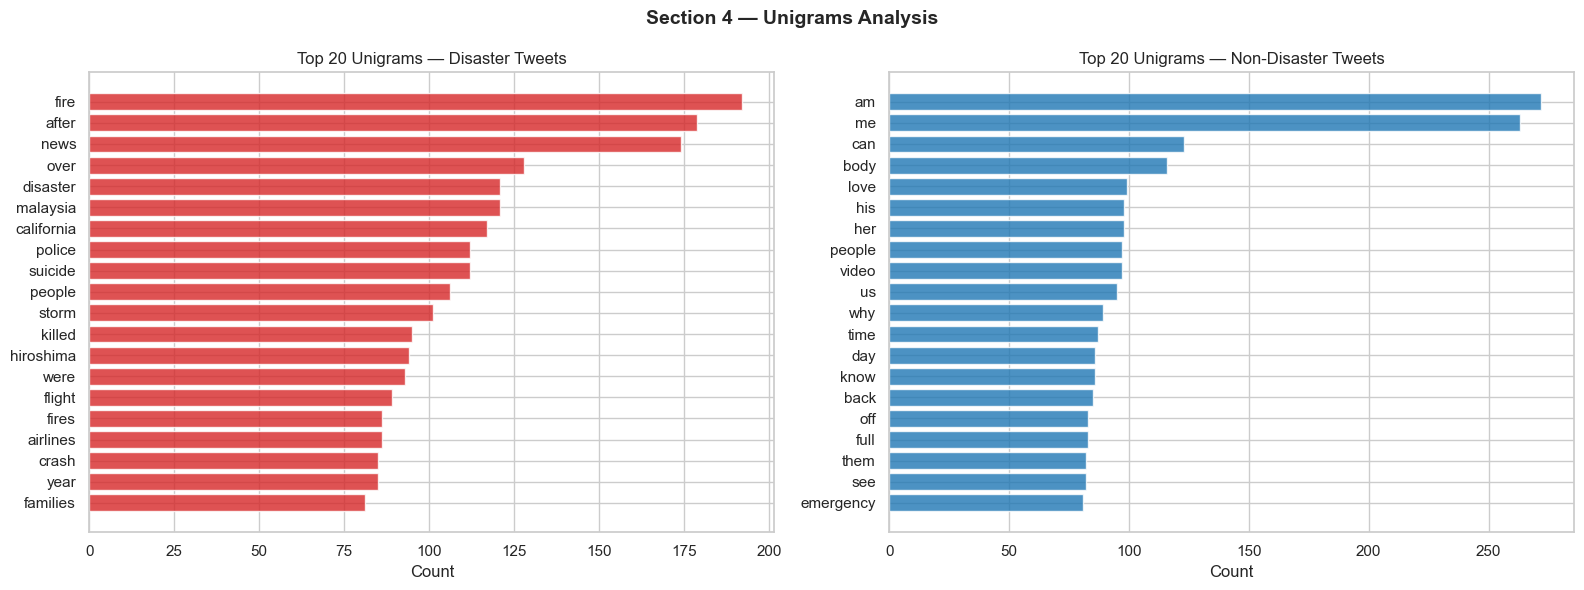


Top 10 Unigrams — Disaster:
  fire                                     192
  after                                    179
  news                                     174
  over                                     128
  disaster                                 121
  malaysia                                 121
  california                               117
  police                                   112
  suicide                                  112
  people                                   106

Top 10 Unigrams — Non-Disaster:
  am                                       272
  me                                       263
  can                                      123
  body                                     116
  love                                     99
  his                                      98
  her                                      98
  people                                   97
  video                                    97
  us                                       95


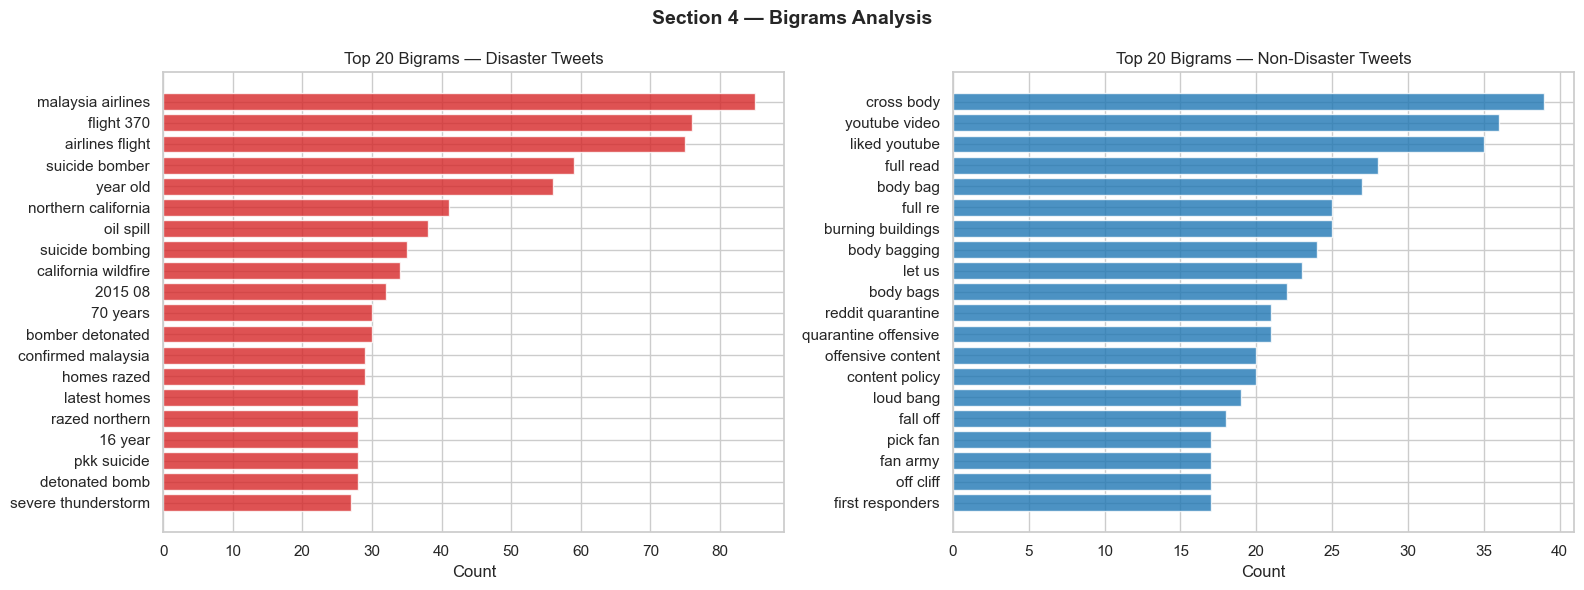


Top 10 Bigrams — Disaster:
  malaysia airlines                        85
  flight 370                               76
  airlines flight                          75
  suicide bomber                           59
  year old                                 56
  northern california                      41
  oil spill                                38
  suicide bombing                          35
  california wildfire                      34
  2015 08                                  32

Top 10 Bigrams — Non-Disaster:
  cross body                               39
  youtube video                            36
  liked youtube                            35
  full read                                28
  body bag                                 27
  full re                                  25
  burning buildings                        25
  body bagging                             24
  let us                                   23
  body bags                                22


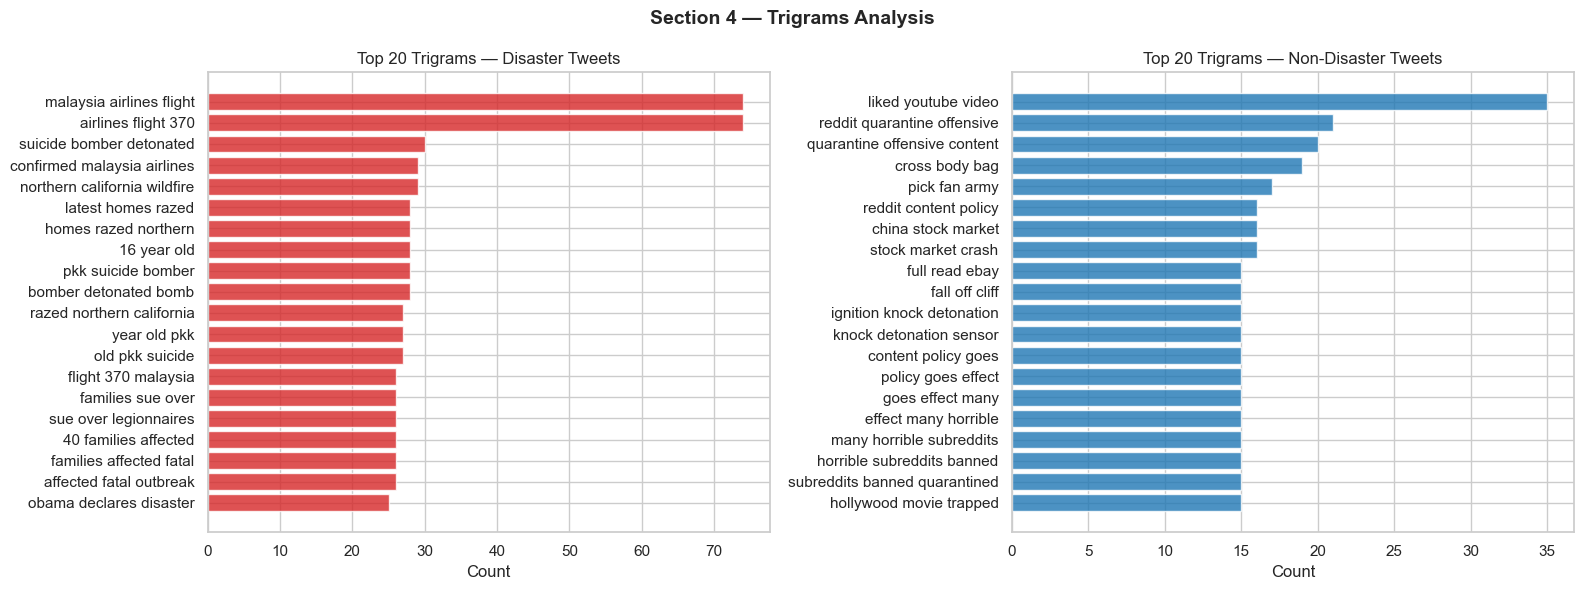


Top 10 Trigrams — Disaster:
  malaysia airlines flight                 74
  airlines flight 370                      74
  suicide bomber detonated                 30
  confirmed malaysia airlines              29
  northern california wildfire             29
  latest homes razed                       28
  homes razed northern                     28
  16 year old                              28
  pkk suicide bomber                       28
  bomber detonated bomb                    28

Top 10 Trigrams — Non-Disaster:
  liked youtube video                      35
  reddit quarantine offensive              21
  quarantine offensive content             20
  cross body bag                           19
  pick fan army                            17
  reddit content policy                    16
  china stock market                       16
  stock market crash                       16
  full read ebay                           15
  fall off cliff                           15


In [56]:
# =============================================================================
# SECTION 4 — N-GRAM ANALYSIS
# =============================================================================
# We extract the most frequent unigrams, bigrams, and trigrams for each class.
# This reveals which words and phrases are characteristic of real disaster
# tweets vs non-disaster tweets, and helps validate that the cleaning worked.
 
print("\n--- N-GRAM ANALYSIS ---")
 
def generate_ngrams(text, n=1):
    """Tokenize text and return n-grams, removing stopwords and punctuation."""
    tokens = [
        t for t in str(text).lower().split()
        if t not in STOPWORDS
        and t not in string.punctuation
        and len(t) > 1
    ]
    ngrams = zip(*[tokens[i:] for i in range(n)])
    return [' '.join(gram) for gram in ngrams]
 
 
def get_top_ngrams(texts, n=1, top_k=20):
    """Count n-grams across all texts and return the top_k most frequent."""
    counts = defaultdict(int)
    for text in texts:
        for gram in generate_ngrams(text, n):
            counts[gram] += 1
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    return sorted_counts[:top_k]
 
 
disaster_texts     = df_train.loc[DISASTER, 'text_cleaned']
nondisaster_texts  = df_train.loc[NON_DISASTER, 'text_cleaned']
 
for n, label in [(1, 'Unigrams'), (2, 'Bigrams'), (3, 'Trigrams')]:
 
    top_disaster    = get_top_ngrams(disaster_texts, n=n, top_k=20)
    top_nondisaster = get_top_ngrams(nondisaster_texts, n=n, top_k=20)
 
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
    # Disaster side
    words_d, counts_d = zip(*top_disaster)
    axes[0].barh(list(words_d)[::-1], list(counts_d)[::-1],
                 color=DISASTER_COLOR, alpha=0.8)
    axes[0].set_title(f'Top 20 {label} — Disaster Tweets', fontsize=12)
    axes[0].set_xlabel('Count')
 
    # Non-disaster side
    words_nd, counts_nd = zip(*top_nondisaster)
    axes[1].barh(list(words_nd)[::-1], list(counts_nd)[::-1],
                 color=NON_DISASTER_COLOR, alpha=0.8)
    axes[1].set_title(f'Top 20 {label} — Non-Disaster Tweets', fontsize=12)
    axes[1].set_xlabel('Count')
 
    plt.suptitle(f'Section 4 — {label} Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../data/images/eda_04_{label.lower()}.png', bbox_inches='tight')
    plt.show()
 
    print(f"\nTop 10 {label} — Disaster:")
    for gram, count in top_disaster[:10]:
        print(f"  {gram:40s} {count}")
    print(f"\nTop 10 {label} — Non-Disaster:")
    for gram, count in top_nondisaster[:10]:
        print(f"  {gram:40s} {count}")


--- TRAIN / TEST CONSISTENCY ---


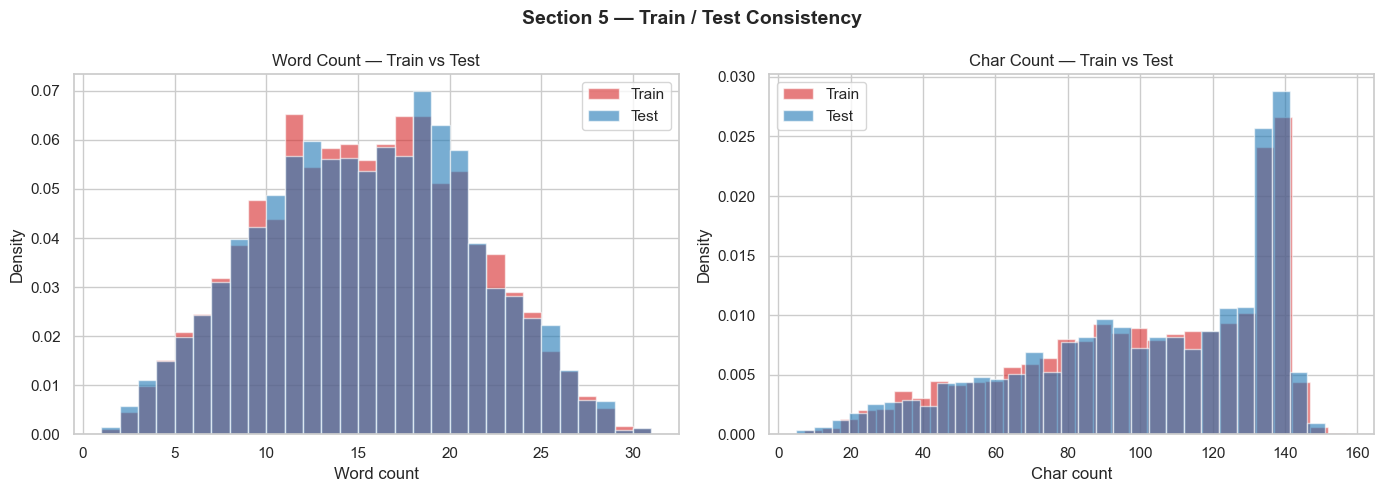


Mean values — Train vs Test:
                    Train    Test
word_count          14.90   14.97
unique_word_count   14.34   14.41
char_count         101.16  102.24
mean_word_length     6.13    6.18
url_count            0.62    0.63
hashtag_count        0.45    0.47
mention_count        0.36    0.39
punctuation_count    6.84    6.95


In [57]:
# =============================================================================
# SECTION 5 — TRAIN / TEST CONSISTENCY
# =============================================================================
# We verify that the training and test sets have similar distributions
# (they were sampled from the same source). If they were very different,
# a model trained on train might generalize poorly to test.
 
print("\n--- TRAIN / TEST CONSISTENCY ---")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Word count distribution: train vs test
axes[0].hist(df_train['word_count'], bins=30, alpha=0.6,
             color=DISASTER_COLOR, label='Train', density=True)
axes[0].hist(df_test['word_count'], bins=30, alpha=0.6,
             color=NON_DISASTER_COLOR, label='Test', density=True)
axes[0].set_title('Word Count — Train vs Test', fontsize=12)
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Density')
axes[0].legend()
 
# Char count distribution: train vs test
axes[1].hist(df_train['char_count'], bins=30, alpha=0.6,
             color=DISASTER_COLOR, label='Train', density=True)
axes[1].hist(df_test['char_count'], bins=30, alpha=0.6,
             color=NON_DISASTER_COLOR, label='Test', density=True)
axes[1].set_title('Char Count — Train vs Test', fontsize=12)
axes[1].set_xlabel('Char count')
axes[1].set_ylabel('Density')
axes[1].legend()
 
plt.suptitle('Section 5 — Train / Test Consistency',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/images/eda_05_train_test_consistency.png', bbox_inches='tight')
plt.show()
 
# Summary statistics comparison
print("\nMean values — Train vs Test:")
comparison = pd.DataFrame({
    'Train': df_train[META_FEATURES].mean(),
    'Test' : df_test[META_FEATURES].mean()
}).round(2)
print(comparison)

In [58]:
# =============================================================================
# SUMMARY
# =============================================================================
 
print("\n" + "="*60)
print("EDA SUMMARY")
print("="*60)
print(f"Training samples       : {len(df_train)}")
print(f"Test samples           : {len(df_test)}")
print(f"Disaster tweets        : {DISASTER.sum()} ({DISASTER.mean():.1%})")
print(f"Non-disaster tweets    : {NON_DISASTER.sum()} ({NON_DISASTER.mean():.1%})")
print(f"Unique keywords        : {df_train['keyword'].nunique()}")
print(f"Avg words (disaster)   : {df_train.loc[DISASTER, 'word_count'].mean():.1f}")
print(f"Avg words (non-dis.)   : {df_train.loc[NON_DISASTER, 'word_count'].mean():.1f}")
print(f"Avg chars (disaster)   : {df_train.loc[DISASTER, 'char_count'].mean():.1f}")
print(f"Avg chars (non-dis.)   : {df_train.loc[NON_DISASTER, 'char_count'].mean():.1f}")
print("="*60)
print("\nPlots saved in ../data/images/")


EDA SUMMARY
Training samples       : 7613
Test samples           : 3263
Disaster tweets        : 3261 (42.8%)
Non-disaster tweets    : 4352 (57.2%)
Unique keywords        : 222
Avg words (disaster)   : 15.2
Avg words (non-dis.)   : 14.7
Avg chars (disaster)   : 108.3
Avg chars (non-dis.)   : 95.8

Plots saved in ../data/images/
